# Fine-Tuning

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from datasets import Dataset
from peft import LoraConfig, TaskType
import xgboost as xgb
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2026-05-06 13:05:47.719811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 13:05:48.261791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/dkusmenko/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving

In [2]:
import os
# This enables memory fragmentation handling specifically for AMD HIP
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return

    # On AMD ROCm, 'cuda' functions query the HIP backend
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 0.00 GB
Allocated (Active): 0.00 GB
Free (Approx): 15.82 GB
------------------------------


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


# Data Import, Clean, and Sample

In [4]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load in freMTPL2freq dataset
dataset = fetch_openml(data_id=41214, as_frame=True)
full_df = dataset.frame

# Clean basic types first
full_df['ClaimNb'] = pd.to_numeric(full_df['ClaimNb'])
full_df['Exposure'] = pd.to_numeric(full_df['Exposure'])
full_df['Exposure'] = full_df['Exposure'].clip(upper=1.0)
full_df['Frequency'] = full_df['ClaimNb'] / full_df['Exposure']

# mapping for contextualized factors
brand_mapping = {'B1': 'Renault, Nissan, or Citroen', 'B2': 'Renault, Nissan, or Citroen',
                 'B3': 'Volkswagen, Audi, Skoda, or Seat', 'B4': 'Opel, General Motors, or Ford',
                 'B5': 'Opel, General Motors, or Ford','B6': 'Fiat', 'B10':'Mercedes, Chrysler, or BMW',
                 'B11':'Mercedes, Chrysler, or BMW', 'B12': 'Japanese (except Nissan) or Korean', 'B13': 'Other','B14': 'Other' }

region_mapping = {
    "R11": "Île-de-France",
    "R21": "Champagne-Ardenne",
    "R22": "Picardie",
    "R23": "Haute-Normandie",
    "R24": "Centre",
    "R25": "Basse-Normandie",
    "R26": "Bourgogne",
    "R31": "Nord–Pas-de-Calais",
    "R41": "Lorraine",
    "R42": "Alsace",
    "R43": "Franche–Comté",
    "R52": "Pays de la Loire",
    "R53": "Bretagne",
    "R54": "Poitou–Charentes",
    "R72": "Aquitaine",
    "R73": "Midi–Pyrénées",
    "R74": "Limousin",
    "R82": "Rhône–Alpes",
    "R83": "Auvergne",
    "R91": "Languedoc–Roussillon",
    "R93": "Provence–Alpes–Côte d’Azur",
    "R94": "Corse"
}

area_mapping = {
    "A": "rural area",
    "B": "semi-rural area",
    "C": "suburban-fringe area",
    "D": "suburban area",
    "E": "urban area",
    "F": "urban center"
}

gas_mapping = {
    "'Diesel'": "Diesel",
    "'Regular'": "Regular"

}

full_df["VehBrand"] = full_df["VehBrand"].map(brand_mapping)
full_df["Region"] = full_df["Region"].map(region_mapping)
full_df["Area"] = full_df["Area"].map(area_mapping)
full_df["VehGas"] = full_df["VehGas"].map(gas_mapping)


In [5]:
# Load the split indices
df_splits = pd.read_csv('freMTPL2freq_split_indices.csv')

# Ensure IDpol is the same type in both dataframes for a clean merge
full_df['IDpol'] = full_df['IDpol'].astype(int)
df_splits['IDpol'] = df_splits['IDpol'].astype(int)

# Merge the dataset with the split indicators
# We use a left join to keep the original data rows
df_merged = full_df.merge(df_splits, on='IDpol', how='left')

# Create the subsets based on the indicator columns
train_df = df_merged[df_merged['is_train'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
test_df = df_merged[df_merged['is_test'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
finetune_df = df_merged[df_merged['is_finetune'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()

# Print results
print(f"Total rows: {len(full_df)}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Finetune rows: {len(finetune_df)}")

# Inspect the training set
print(train_df.head())

Total rows: 678013
Train rows: 500000
Test rows: 100000
Finetune rows: 76782
   IDpol  ClaimNb  Exposure                  Area  VehPower  VehAge  DrivAge  \
1      3        1      0.77         suburban area         5       0       55   
3     10        1      0.09       semi-rural area         7       0       46   
4     11        1      0.84       semi-rural area         7       0       46   
5     13        1      0.52            urban area         6       2       38   
7     17        1      0.27  suburban-fringe area         7       0       33   

   BonusMalus                            VehBrand   VehGas  Density  \
1          50  Japanese (except Nissan) or Korean  Regular     1217   
3          50  Japanese (except Nissan) or Korean   Diesel       76   
4          50  Japanese (except Nissan) or Korean   Diesel       76   
5          50  Japanese (except Nissan) or Korean  Regular     3003   
7          68  Japanese (except Nissan) or Korean   Diesel      137   

               

# Create Prompts

In [6]:
# ==========================================
# 2. SERIALIZATION (Tabular -> Text)
# ==========================================
def serialize_row(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (f"""You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: {row['DrivAge']} years old (in France people can drive starting at age 18)
- Land Type: {area}
- Region: {region}, France
- Population density: {row['Density']} people/km2 (average density is 1792 people/km2)
- Vehicle: {veh_brand}
- Vehicle Age: {row['VehAge']} years old
- Fuel type: {veh_gas} (either Diesel or Regular Gasoline)
- Power class: {row['VehPower']} (min = 4, max = 15)
- Bonus-Malus score: {row['BonusMalus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)"""
    )

# Apply serialization
print("Serializing rows to text...")
train_df['text_desc'] = train_df.apply(serialize_row, axis=1)
test_df['text_desc'] = test_df.apply(serialize_row, axis=1)

Serializing rows to text...


### Example Prompt

A policyholder is 35 years old living in a suburban-fringe area of Poitou–Charentes, France with a population density 233 people/km2. They drive a Opel, General Motors, or Ford vehicle which runs on Diesel fuel with a vehicle power class of 5 (min = 4, max = 15). The vehicle age is 7 years and the driver's bonus-malus score is 50 (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus).

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [7]:
# Initialize Model
model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B", 
    trust_remote_code=True, 
    device="cuda",
    model_kwargs={
        "torch_dtype": torch.float16,   # Critical for speed/VRAM
        "attn_implementation": "sdpa"   # Faster attention
    }
)

`torch_dtype` is deprecated! Use `dtype` instead!
/home/dkusmenko/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


In [8]:
# Test Model works
print("Model loaded successfully!")
with model.truncate_sentence_embeddings(truncate_dim=64):
    embeddings_truncated = model.encode(["hello there", "hiya"])
assert embeddings_truncated.shape[-1] == 64

Model loaded successfully!


/usr/lib/python3.10/contextlib.py:103: FutureWarning: The `truncate_sentence_embeddings` method has been renamed to `truncate_embeddings`.
  self.gen = func(*args, **kwds)
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:256.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:302.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [9]:
embeddings_truncated

array([[-1.8784e-02, -5.9357e-03, -9.9487e-03, -4.6478e-02, -3.4499e-04,
        -2.1687e-03, -4.1290e-02,  2.6505e-02, -9.2468e-02,  1.5198e-02,
         2.1820e-03, -2.9907e-02,  1.0095e-01, -8.7357e-03, -4.7638e-02,
         7.6416e-02, -2.5848e-02,  6.2225e-02,  1.0931e-01, -8.1299e-02,
         3.3081e-02,  9.8038e-03, -3.9032e-02,  1.3342e-01,  5.8842e-04,
        -7.8583e-03, -3.0991e-02,  1.0962e-01,  1.2772e-02, -3.5858e-03,
         1.7761e-02,  3.5187e-02, -1.1078e-02,  4.0169e-03, -3.4760e-02,
        -1.2779e-02, -1.7044e-02, -1.1711e-03, -2.9800e-02,  5.6976e-02,
        -1.7181e-02,  2.9373e-02,  6.8726e-02, -1.9272e-02, -6.6638e-05,
        -3.1174e-02,  5.5084e-02, -1.4748e-02,  1.0414e-03, -9.4604e-03,
        -2.7710e-02, -2.5681e-02,  1.4664e-02,  8.5526e-03,  9.0714e-03,
        -5.8838e-02,  5.4932e-02, -3.5591e-03,  3.7079e-02, -8.3542e-03,
        -9.2957e-02,  4.6600e-02, -2.4231e-02,  9.5062e-03],
       [-1.6165e-03,  1.8890e-02, -1.5717e-02, -5.3925e-02,  2.

Model is outputting embeddings of dim 64

### Check VRAM Usage

In [10]:
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 1.21 GB
Allocated (Active): 1.11 GB
Free (Approx): 14.61 GB
------------------------------


Now want to generate embeddings from data

Ensure model is running on GPU

In [11]:
print(model.device)

cuda:0


In [12]:
import torch

# 1. Define the device (On AMD ROCm, we still call it 'cuda' in PyTorch)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Moving model to: {device}")

# 2. Move the model
model = model.to(device)

Moving model to: cuda


In [13]:
print("Generating embeddings for GLM...")

train_embeddings= model.encode(train_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)
test_embeddings = model.encode(test_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)

Generating embeddings for GLM...


Batches:   0%|          | 0/7813 [00:00<?, ?it/s]

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

In [14]:
import numpy as np

# Save everything in one single archive
np.savez(
    "embeddings/train_baseqwen.npz", 
    X=train_embeddings,           # The Features (Embeddings)
    y=train_df['ClaimNb'].values, # The Target (Counts)
    w=train_df['Exposure'].values # The Weight (Exposure)
)
print("Saved all training data to embeddings/train_baseqwen.npz")
np.savez(
    "embeddings/test_baseqwen.npz", 
    X=test_embeddings,           # The Features (Embeddings)
    y=test_df['ClaimNb'].values, # The Target (Counts)
    w=test_df['Exposure'].values # The Weight (Exposure)
)

print("Saved all testing data to embeddings/test_baseqwen.npz")



Saved all training data to embeddings/train_baseqwen.npz
Saved all testing data to embeddings/test_baseqwen.npz


In [2]:
import numpy as np
train_df = np.load("embeddings/train_baseqwen.npz")

test_df = np.load("embeddings/test_baseqwen.npz")

# Clustering

In [3]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=48).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(48)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

full_embeddings = pd.concat([X_train_pca, X_test_pca])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = full_embeddings

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize and fit the model
# Choose 5, 10, 20 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
full_embeddings['Cluster_5'] = kmeans.fit_predict(X_scaled)

kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
full_embeddings['Cluster_10'] = kmeans.fit_predict(X_scaled)

kmeans = KMeans(n_clusters=20, random_state=42, n_init='auto')
full_embeddings['Cluster_20'] = kmeans.fit_predict(X_scaled)

# View the result
print(full_embeddings.head())

         PC1        PC2        PC3        PC4       PC5        PC6       PC7  \
0  15.310307   8.990679 -10.267797   2.634130 -3.456980   4.424897 -0.820731   
1  13.361327  11.378126  12.057166   9.178955 -2.067735   5.622818  1.206991   
2  13.407091  11.418993  12.020130   9.199942 -2.113281   5.646997  1.195243   
3  18.563196  14.571923   6.537592  -2.279069  3.239272 -10.736015  8.748997   
4  16.671796   7.289340  -7.038250  13.610195 -1.339093  -2.388616  0.027084   

        PC8        PC9       PC10  ...      PC42      PC43      PC44  \
0 -4.974869 -15.895921  10.834917  ... -0.374470  0.745681  2.369752   
1  1.495947   3.993313  -1.292162  ...  0.287055  2.363388  1.030384   
2  1.497379   3.972074  -1.253709  ...  0.278908  2.363709  1.027393   
3 -4.289826  -0.417671   1.058828  ... -0.837191 -0.734260 -0.696355   
4  0.733989   5.359518 -11.200463  ... -0.807705  0.281651  2.797935   

       PC45      PC46      PC47      PC48  Cluster_5  Cluster_10  Cluster_20  
0 -0.19

/home/dkusmenko/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


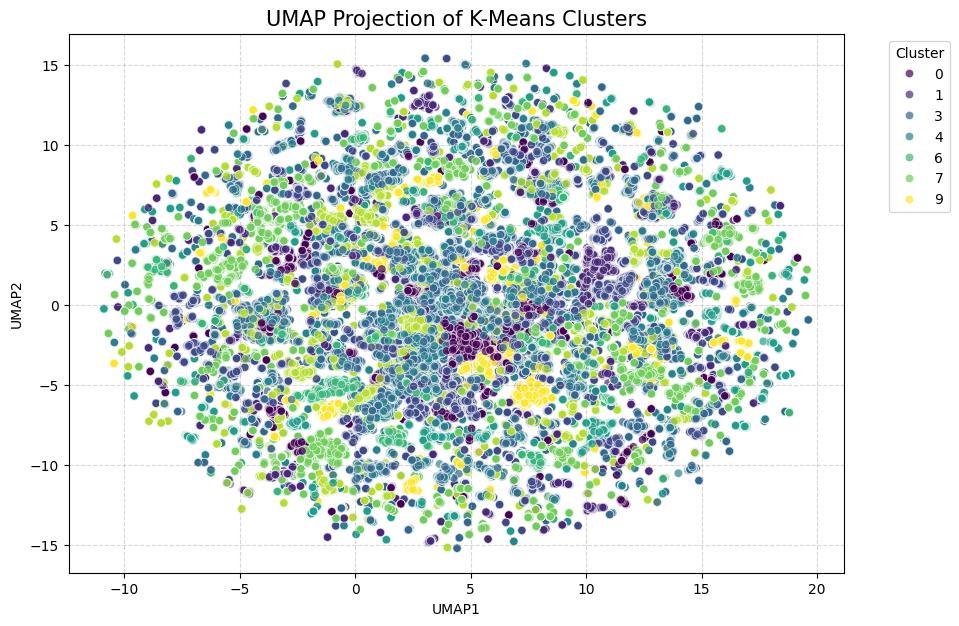

In [5]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize UMAP
# n_neighbors: balances local vs global structure (usually 5 to 50)
# min_dist: controls how tightly points are packed together (usually 0.1 to 0.5)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)

# 2. Fit and transform the scaled data
# Use the X_scaled variable from the K-Means step
embedding = reducer.fit_transform(X_scaled)

# 3. Create a plotting DataFrame
plot_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
plot_df['Cluster_10'] = full_embeddings['Cluster_10'].values

# 4. Visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df, 
    x='UMAP1', 
    y='UMAP2', 
    hue='Cluster_10', 
    palette='viridis', 
    alpha=0.7,
    edgecolor='w'
)

plt.title('UMAP Projection of K-Means Clusters', fontsize=15)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()